In [26]:
import json
import pandas as pd
from pathlib import Path

here = Path.cwd()  # notebook's working dir
print("CWD:", here)

# walk upward until we find a folder that contains "runs/"
repo_root = next(p for p in [here] + list(here.parents) if (p / "runs").exists())

runs_dir = repo_root / "runs"
latest_run_dir = max([d for d in runs_dir.iterdir() if d.is_dir()], key=lambda d: d.stat().st_mtime)

eval_path = latest_run_dir / "eval.json"
print("Using:", eval_path)

with eval_path.open("r", encoding="utf-8") as f:
    eval_info = json.load(f)

df = pd.json_normalize(eval_info)
curve_df = pd.DataFrame(df['components.coverage_curve'][0])
curve_df

CWD: c:\Users\purpa\OneDrive\Desktop\Projects\godot-issue-triager\src\scripts
Using: c:\Users\purpa\OneDrive\Desktop\Projects\godot-issue-triager\runs\20260226_145821\eval.json


,threshold,coverage,avg_pred_labels,micro_f1_all,macro_f1_all,hamming_loss_all,micro_f1_covered,macro_f1_covered,hamming_loss_covered
0,0.050000,1.000000,15.470718,0.163819,0.146035,0.782803,0.163819,0.146035,0.782803
1,0.081034,1.000000,11.878471,0.207913,0.183991,0.583448,0.207913,0.183991,0.583448
2,0.112069,1.000000,9.222711,0.259005,0.243085,0.436486,0.259005,0.243085,0.436486
3,0.143103,1.000000,7.408578,0.310777,0.306935,0.336526,0.310777,0.306935,0.336526
4,0.174138,1.000000,6.077811,0.363355,0.367877,0.263786,0.363355,0.367877,0.263786
5,0.205172,1.000000,5.065164,0.415408,0.422610,0.209330,0.415408,0.422610,0.209330
6,0.236207,1.000000,4.301622,0.465425,0.468580,0.168744,0.465425,0.468580,0.168744
7,0.267241,1.000000,3.715425,0.509685,0.507514,0.138805,0.509685,0.507514,0.138805
8,0.298276,0.999725,3.265878,0.546929,0.536453,0.116946,0.546993,0.536609,0.116948
9,0.329310,0.999450,2.900467,0.580384,0.563845,0.099792,0.580533,0.564098,0.099786


In [31]:
rows = []
for task, info in eval_info.items():
    m_all = info.get("metrics_all", {}) or {}
    m_cov = info.get("metrics_at_coverage", {}) or {}
    rows.append({
        "task": task,
        "micro_f1": m_all.get("micro_f1"),
        "macro_f1": m_all.get("macro_f1"),
        "hamming_loss": m_all.get("hamming_loss"),
        "coverage": m_all.get("coverage"),
        "avg_pred_labels": m_all.get("avg_pred_labels"),
        "micro_f1_covered": m_cov.get("micro_f1"),
        "hit@5": info.get("hit_at_5"),
        "recall@5_micro": info.get("recall_at_5_micro"),
    })

metrics_df = pd.DataFrame(rows).set_index("task").sort_index()
metrics_df

,micro_f1,macro_f1,hamming_loss,coverage,avg_pred_labels,micro_f1_covered,hit@5,recall@5_micro
task,,,,,,,,
components,0.672571,0.643963,0.053646,0.919989,1.568875,0.694656,0.966731,0.960558
impact,0.609792,0.581957,0.072312,0.320319,0.363211,0.729370,0.340665,1.000000
issue_type,0.771688,0.333343,0.107094,0.914765,0.965356,0.800547,0.910916,1.000000
platform,0.674419,0.682604,0.024636,0.192741,0.196866,0.779832,0.177344,1.000000


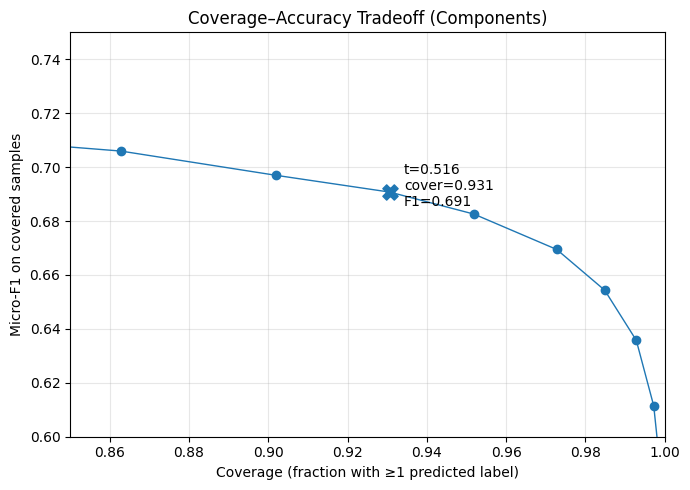

In [27]:
import matplotlib.pyplot as plt

# --- make sure we plot in coverage order ---
plot_df = curve_df.copy()
plot_df = plot_df.sort_values("threshold")  # x-axis increasing looks nicer

# --- find & mark the tuned operating point (closest coverage to your saved single-point) ---
target_cov = eval_info["components"]["coverage"]          # from eval.json single-point
i_star = (plot_df["coverage"] - target_cov).abs().idxmin()
star = plot_df.loc[i_star]

plt.figure(figsize=(7, 5))
plt.plot(plot_df["coverage"], plot_df["micro_f1_covered"], marker="o", linewidth=1)

# mark tuned point
plt.scatter([star["coverage"]], [star["micro_f1_covered"]], s=120, marker="X", zorder=5)
plt.annotate(
    f"t={star['threshold']:.3f}\ncover={star['coverage']:.3f}\nF1={star['micro_f1_covered']:.3f}",
    (star["coverage"], star["micro_f1_covered"]),
    textcoords="offset points",
    xytext=(10, -10),
)

plt.xlim(0.85, 1.0)
plt.ylim(0.60, 0.75)   # adjust to your range

plt.xlabel("Coverage (fraction with ≥1 predicted label)")
plt.ylabel("Micro-F1 on covered samples")
plt.title("Coverage–Accuracy Tradeoff (Components)")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [28]:
import json
import pandas as pd
from pathlib import Path

data_dir = repo_root / "src" / "scripts" / "data_collection" / "data" / "processed"
paths = {
    "train": data_dir / "train.json",
    "val":   data_dir / "val.json",
    "test":  data_dir / "test.json",
}
vocab_path = data_dir / "label_vocab.json"

def load_df(p: Path) -> pd.DataFrame:
    with p.open("r", encoding="utf-8") as f:
        return pd.DataFrame(json.load(f))

dfs = {k: load_df(p) for k, p in paths.items()}

with vocab_path.open("r", encoding="utf-8") as f:
    vocab = json.load(f)

components_vocab = set(vocab["components"])
has_other = "other" in components_vocab

# ---- dataset/split summary ----
def date_range(df: pd.DataFrame):
    # try common timestamp columns; adjust if yours differs
    for col in ["created_at", "createdAt", "created_utc", "created"]:
        if col in df.columns:
            ts = pd.to_datetime(df[col], errors="coerce", utc=True)
            return ts.min(), ts.max(), col
    return None, None, None

rows = []
for split, df in dfs.items():
    mn, mx, col = date_range(df)

    # label cardinality for components (assumes df["topic"] is list[str])
    if "topic" in df.columns:
        y = df["topic"].apply(lambda x: x if isinstance(x, list) else [])
        avg_true_labels = float(y.apply(len).mean())
        frac_other = float(y.apply(lambda lst: ("other" in lst)).mean()) if has_other else None
    else:
        avg_true_labels = None
        frac_other = None

    rows.append({
        "split": split,
        "n_issues": len(df),
        "date_col": col,
        "date_min": None if mn is None else str(mn.date()),
        "date_max": None if mx is None else str(mx.date()),
        "avg_true_components": avg_true_labels,
        "frac_issues_with_other": frac_other,
    })

split_summary = pd.DataFrame(rows)
split_summary

,split,n_issues,date_col,date_min,date_max,avg_true_components,frac_issues_with_other
0,train,12727,created_at,2023-03-27,2025-02-06,1.442602,0.101831
1,val,1818,created_at,2025-02-06,2025-05-29,1.391639,0.078108
2,test,3637,created_at,2025-05-29,2026-02-11,1.380258,0.083035


In [29]:
# ---- component frequency in TRAIN (or overall) ----
train_df = dfs["train"]
y = train_df["topic"].apply(lambda x: x if isinstance(x, list) else [])
freq = y.explode().value_counts(dropna=True)

top10 = freq.head(10).reset_index()
top10.columns = ["component", "count"]

label_vocab_summary = {
    "N_components_in_vocab": len(components_vocab),
    "has_other": has_other,
    "min_support_in_train_for_vocab_labels": int(freq.loc[list(components_vocab)].min()) if len(components_vocab) else None,
}
top10, label_vocab_summary

(   component  count
 0     editor   4075
 1  rendering   1977
 2         3d   1604
 3        gui   1426
 4      other   1296
 5       core   1117
 6   gdscript    991
 7         2d    978
 8  platforms    710
 9  animation    682,
 {'N_components_in_vocab': 18,
  'has_other': True,
  'min_support_in_train_for_vocab_labels': 243})

In [30]:
import json
from pathlib import Path

run_dir = Path(latest_run_dir)  # you already have this
summary_path = run_dir / "schema_validation_summary.json"

summary = json.loads(summary_path.read_text(encoding="utf-8"))
print("valid_rate:", summary["valid_rate"])
print("valid_count:", summary["valid_count"], "/", summary["total"])
print("top_errors (first 5):", summary["top_errors"][:5])

valid_rate: 1.0
valid_count: 3637 / 3637
top_errors (first 5): []


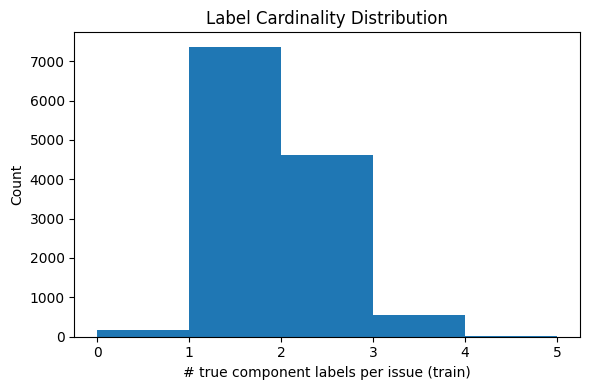

In [32]:
import matplotlib.pyplot as plt

train_y = dfs["train"]["topic"].apply(lambda x: x if isinstance(x, list) else [])
card = train_y.apply(len)

plt.figure(figsize=(6,4))
plt.hist(card, bins=range(0, int(card.max())+2))
plt.xlabel("# true component labels per issue (train)")
plt.ylabel("Count")
plt.title("Label Cardinality Distribution")
plt.tight_layout()
plt.show()